![](img/car_accident.jpg){width=500}

When I was in high school and I would tell my mom that I was going out with my friends, she would always ask "Who's driving? Your friend or their parents?" She was always uncomfortable with the idea of my peers driving me around, explaining "I just don't trust their skills." Fortunately, I was never in a car accident with any of my friends in high school, but I always wonder, *did she have a point? Are teenage drivers really more dangerous or prone to accidents than adults?* Using open crash data from the Police Crash Report database, I seek to answer this question by comparing the count of and conditions surrounding car accidents involving teenagers (16 - 19 years old) and adults in Philadelphia between 2005 and 2024 (the span of the data). 

Before jumping into the analysis, it's important to note that the data did not contain a direct variable that stated the age of the driver at fault - it simply counted the amount of teenage drivers involved in the incident. Thus, as a proxy, this analysis compares accidents that involved teenagers to accidents that did not, even though it's possible that the teenagers were not at fault.

Set up

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

In [2]:
crash = pd.read_csv('data/PDOT_crash_data_2005_2024.csv', low_memory=False)

The first thing I wanted to compare was the total amount of crashes that teenagers and non-teenagers had been involved in.

Creating a variable for whether any teens were involved in crash

In [3]:
crash["teen_involved"] = (
    (crash["DRIVER_COUNT_16YR"] > 0) |
    (crash["DRIVER_COUNT_17YR"] > 0) |
    (crash["DRIVER_COUNT_18YR"] > 0) |
    (crash["DRIVER_COUNT_19YR"] > 0)

)

In [4]:
crash["teen_involved"].value_counts()

teen_involved
False    602394
True      88675
Name: count, dtype: int64

Creating pie chart to show percentage breakdown

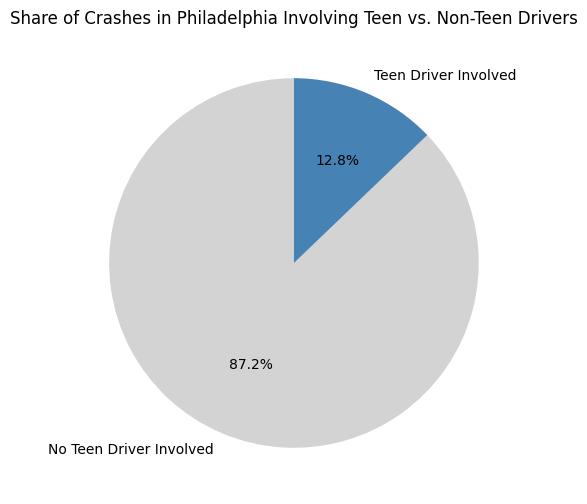

In [5]:
counts = crash["teen_involved"].value_counts()

labels = ["No Teen Driver Involved", "Teen Driver Involved"]
sizes = [counts[False], counts[True]]

plt.figure(figsize = (6, 6))
plt.pie(
    sizes,
    labels = labels,
    autopct = "%1.1f%%",
    startangle = 90,
    colors = ["lightgray", "steelblue"]
)

plt.title("Share of Crashes in Philadelphia Involving Teen vs. Non-Teen Drivers")
plt.show() #Used ChatGPT for help on pie chart

Between 2005 and 2024, teenagers were involved in 88,675 car crashes compared to non-teenagers' 602,394, representing just 12.8% of the total share of crashes in this period. It's worth mentioning that there are way more adult drivers than teenagers so neither the total count or percentage share really tell us that much. It's far more helpful to understand the circumstances that surround accidents involving these two groups. For example, what times of day and days of the week did teenager and non-teenager crashes most often occur?

Time of day

Creating bins for the hours

In [6]:
crash["hours"] = pd.cut(
    crash["HOUR_OF_DAY"],
    bins = [-1, 5, 11, 17, 23],
    labels = ["12-5AM", "6-11AM", "12-5PM", "6-11PM"]
)

Creating prop table

In [7]:
hour_prop = pd.crosstab(
    crash["hours"],
    crash["teen_involved"],
    normalize = "columns"
)

Creating bar chart

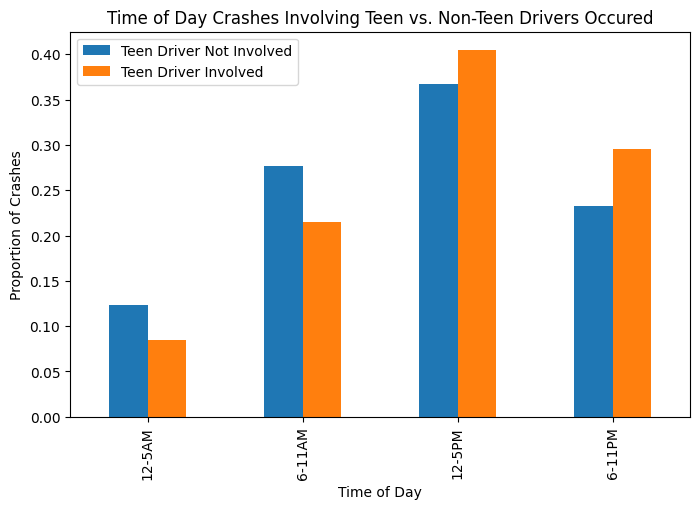

In [8]:
hour_prop.plot(kind = "bar", figsize = (8, 5))
plt.ylabel("Proportion of Crashes")
plt.xlabel("Time of Day")
plt.title("Time of Day Crashes Involving Teen vs. Non-Teen Drivers Occured")
plt.legend(["Teen Driver Not Involved", "Teen Driver Involved"])
plt.show()

Day of week

Creating prop table

In [9]:
day_prop = pd.crosstab(
    crash["DAY_OF_WEEK"],
    crash["teen_involved"],
    normalize = "columns"
)

Creating bar chart

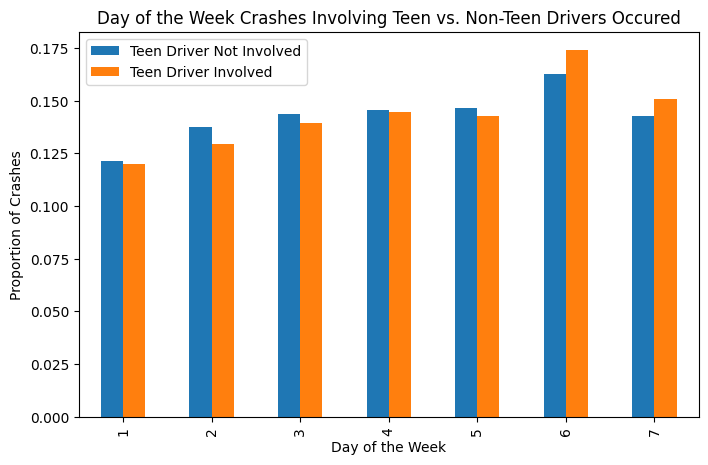

In [10]:
day_prop.plot(kind = "bar", figsize = (8, 5))
plt.ylabel("Proportion of Crashes")
plt.xlabel("Day of the Week")
plt.title("Day of the Week Crashes Involving Teen vs. Non-Teen Drivers Occured")
plt.legend(["Teen Driver Not Involved", "Teen Driver Involved"])
plt.show()

Interestingly, there's a higher proportion of crashes that do not involve teen drivers from 12-11AM and a higher proportion of crashes that do involve teen drivers from 12-11PM. One explanation could be that adults were driving more recklessly in the morning during their commutes as they rushed to work while teens could have beeen driving distracted since they were more likely to have peers in the car with them after school.

If we zoom out to look at the crash patterns over the course of the whole week, these explanations start to take more shape. There's a higher proportion of non-teen crashes from Monday to Friday, further suggesting that they were connected to week day commutes. On the other hand, there's a higher proportion of teen-involved crashes on the weekends, indicating that they were likely taking place in more recreational contexts, perhaps when teens were hanging out with their friends.

While this data helps explain when crashes involving teens were most likely to occur, it is also worth asking where in Philadelphia these crashes were happening.

Creating spatial map for teen-involved car accidents in Philadelphia

In [28]:
philly_gdf = gpd.read_file('data/philadelphia_zip_boundaries.geojson')

In [29]:
geom = gpd.points_from_xy(crash['DEC_LONGITUDE'],
                          crash['DEC_LATITUDE'])

crash_gdf = gpd.GeoDataFrame(crash, geometry = geom)

crash_gdf['teen_involved'] = (
    (crash["DRIVER_COUNT_16YR"] > 0) |
    (crash["DRIVER_COUNT_17YR"] > 0) |
    (crash["DRIVER_COUNT_18YR"] > 0) |
    (crash["DRIVER_COUNT_19YR"] > 0)

)

In [30]:
phil = crash_gdf['COUNTY'] == 67
phil_teen_crashes = crash_gdf[phil & crash_gdf['teen_involved']].set_crs('EPSG:4326')

In [31]:
tgdf = gpd.sjoin(philly_gdf, phil_teen_crashes)

tgdf2 = tgdf.dissolve(by= 'listname', aggfunc = 'count')

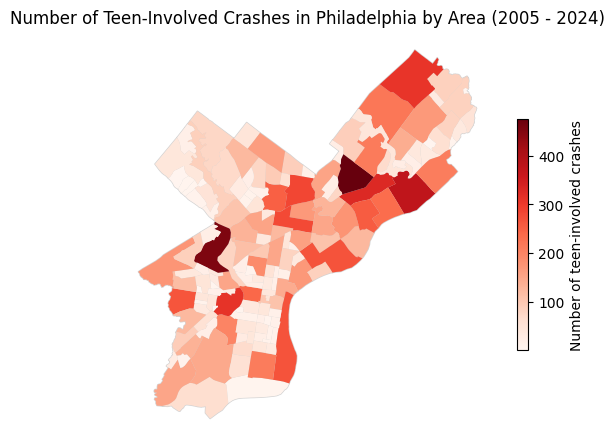

In [32]:
fig = philly_gdf.plot(color = 'white',
                      edgecolor = 'lightgray',
                      figsize = (6, 6))
tgdf2.plot(ax = fig,
           column = 'CRN',
           cmap = 'Reds',
           legend = True,
           legend_kwds = {'shrink': 0.5,
                          'label': 'Number of teen-involved crashes'}
          )

fig.axis('off')
fig.set_title('Number of Teen-Involved Crashes in Philadelphia by Area (2005 - 2024)')

plt.show()

As the map shows, teen-involved crashes were not evenly distributed across Philadelphia but rather concentrated across several different neighborhoods. Notably, these clusters occured in both high traffic areas like Center City and Kensington and lower traffic areas like North and Northeast Philadelphia. This suggests that teen-involved crashes were linked not only to traffic density but also to residential areas and major road corridors.

Part of the reason my mom was so hesitant to let me drive with my friends is because she believed that kids my age "engaged in riskier behaviors while driving." She meant things like driving while under the influence of drugs or alcohol, speeding, and texting while driving. While the data does not record any of those behaviors, a good proxy is driving without a seatbelt, a high risk behavior in itself. So, using driving without a seatbelt as a broader proxy for risky driver behavior, do we find that teen-involved crashes include unbelted occupants at a higher rate compared to adult ones?

Calculating percentage of unbelted occupants in teen involved vs. non teen involved accidents

In [21]:
teen_nosb_pct = (crash[crash['teen_involved']]['UNBELTED_OCC_COUNT'] > 0).mean() * 100

nonteen_nosb_pct = (crash[~crash['teen_involved']]['UNBELTED_OCC_COUNT'] > 0).mean() * 100

In [22]:
print(teen_nosb_pct)
print(nonteen_nosb_pct)

11.440654073865238
10.78729203810131


The percentage of crashes that contained unbelted occupants in teen involved and non-teen crashes is nearly identical at 11.4% and 10.8%, respectively. Thus, it does not appear that teen involved accidents exhibited higher risk behavior.

What about crash severity? Did car accidents that involve teens lead to injuries at a higher rate than non-teens ones?

Calculating percentage of reported injury in teen involved vs. non teen involved accidents

In [23]:
teen_injury_pct = (crash[crash['teen_involved']]['TOT_INJ_COUNT'] > 0).mean() * 100

nonteen_injury_pct = (crash[~crash['teen_involved']]['TOT_INJ_COUNT'] > 0).mean() * 100

In [25]:
print(teen_injury_pct)
print(nonteen_injury_pct)

47.57597970115591
55.583388944777


On the contrary, crashes that involved non-teens lead to injury 55.6% of the time while crashes that involved teenagers lead to injury 47.6% of the time - an eight percentage point difference. In this way, crashes that involved teenagers appear to be less severe than crashes that involved older people. 

Lastly, how has the amount of crashes per yer changed for both groups? 

Plotting annual crash data

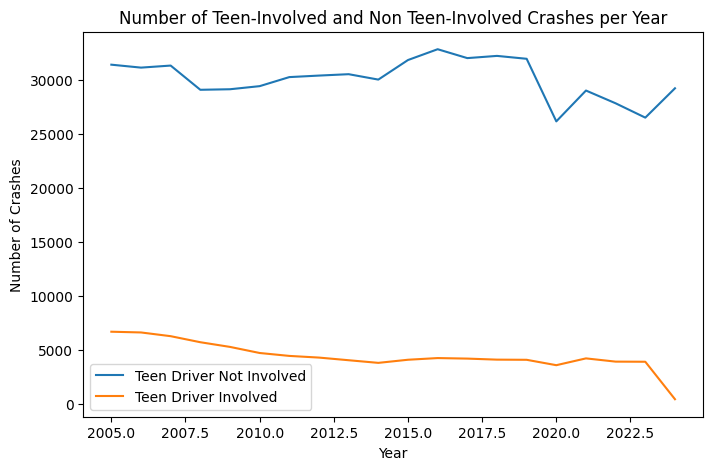

In [27]:
annual_crash_count = crash.groupby(['CRASH_YEAR', 'teen_involved']).size().unstack()

annual_crash_count.plot(figsize = (8, 5))

plt.title("Number of Teen-Involved and Non Teen-Involved Crashes per Year")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.legend(["Teen Driver Not Involved", "Teen Driver Involved"])

plt.show()

Crashes involving teen drivers show a clear overall decline from 2005 to the mid 2010s, remaining relatively stable, before sharply declining again in 2022. In contrast, crashes that do not involve teen drivers stay relatively stable over the same period, fluctuating from year to year but without the same significant decline.

So was my mom right? In Philadelphia between 2005 and 2024, crashes involving teens were less commonn than those involving only adults, declined more rapidly over time, showed similar rates of unbelted occupants, and were less likely to result in injuries. So, from the lens of this analysis, it appears that maybe she wasn't.

Of course, both the data set and conditions used to make some of these claims are highly limited. There are several studies that show that teens are more likely to engage in higher risk behavior while driving and that they crash at higher rates than adults. Still, the patterns in Philadelphia's crash data suggest that teen-involved accidents may not be as uniquely dangerous as they are often assumed to be.